# TP étudiant — Gymnasium avec Taxi-v3 et MiniGrid-Empty-16x16-v0

Complétez les cellules demandées. Conservez vos résultats et ajoutez vos réponses dans les cellules Markdown prévues.

## 0. Installation
Décommentez les lignes si nécessaire.

In [18]:
# %pip install gymnasium
# %pip install "gymnasium[toy-text]"
# %pip install minigrid

print("Décommentez les installations si nécessaire.")

Décommentez les installations si nécessaire.


In [19]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

print(gym.__version__)

1.2.3


## 1. Découverte de Taxi-v3

In [20]:
# Créer l'environnement Taxi-v3
# Afficher action_space, observation_space, spec et unwrapped
env = gym.make("Taxi-v3")
print("Type de l'environnement :", type(env))
print("Action space :", env.action_space)
print("Observation space :", env.observation_space)
print("Spec :", env.spec)

Type de l'environnement : <class 'gymnasium.wrappers.common.TimeLimit'>
Action space : Discrete(6)
Observation space : Discrete(500)
Spec : EnvSpec(id='Taxi-v3', entry_point='gymnasium.envs.toy_text.taxi:TaxiEnv', reward_threshold=8, nondeterministic=False, max_episode_steps=200, order_enforce=True, disable_env_checker=False, kwargs={}, namespace=None, name='Taxi', version=3, additional_wrappers=(), vector_entry_point=None)


**Réponse attendue :** décrivez brièvement ce que représente Taxi-v3 et pourquoi cet environnement est utile pour commencer.

## 2. Premier épisode avec actions aléatoires

In [21]:
# Exécuter un épisode aléatoire complet
# Afficher le nombre d'étapes, la récompense cumulée et la cause d'arrêt
obs, info = env.reset(seed=0)
episode_reward = 0.0
step_count = 0

terminated = False
truncated = False

while not (terminated or truncated):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    episode_reward += reward
    step_count += 1

print("Nombre d'étapes :", step_count)
print("Récompense cumulée :", episode_reward)
print("Cause d'arrêt :", "terminated" if terminated else "truncated")

env.close()


Nombre d'étapes : 200
Récompense cumulée : -749.0
Cause d'arrêt : truncated


**Analyse :** que remarquez-vous sur les performances de cette politique ?

ça donne pas de bonne résultats car la prise d'action est aléatoire.

## 3. Politique aléatoire sur plusieurs épisodes

In [22]:
# Écrire une fonction random_taxi_policy(obs, env)
# Lancer au moins 20 épisodes
# Stocker les résultats dans une liste ou un dictionnaire

"""

Dans la définition de cette policy, on a ajouté un paramètre info.
Cette policy ne l'utilise pas, mais la policy suivante l'utilise.
Donc, pour pouvoir créer une fonction lancer_episodes automatique, il faut que toutes les policies reçoivent les mêmes paramètres.
C'est pour ceci qu'on a ajouté ce paramètre.

"""
def random_taxi_policy(obs, info, env) : 
    action = env.action_space.sample()
    return action

# On crée une fonction qui lance automatiquement des épisodes selon la politique choisie
def lancer_episodes(policy, env, nbre_episodes=50):
    results = []
    
    for episode in range(nbre_episodes):
        obs, info = env.reset(seed=episode)
        terminated = truncated = False
        total_reward = 0.0
        steps = 0

        while not (terminated or truncated):
            action = policy(obs, info, env)
            
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            steps += 1

        results.append({
            "total_reward": total_reward, 
            "steps": steps, 
            "stop_reason": "terminated" if terminated else "truncated"
        })
    env.close()
    return results

results = lancer_episodes(random_taxi_policy, env)

In [23]:
# Calculer les indicateurs moyens : récompense, longueur, taux de succès
def evaluer_politique(results):
    recomp_moyenne = 0
    longueur_moyenne = 0
    taux_succes = 0
    Nbre_episodes = len(results)
    
    for result in results:
        recomp_moyenne += result['total_reward'] / Nbre_episodes
        longueur_moyenne += result['steps'] / Nbre_episodes
        taux_succes += (1 / Nbre_episodes) if result['stop_reason'] == "terminated" else 0
        
    return recomp_moyenne, longueur_moyenne, taux_succes

recomp_moyenne, longueur_moyenne, taux_succes = evaluer_politique(results)
print(f"La récompense moyenne est {recomp_moyenne}")
print(f"La longueur moyenne est {longueur_moyenne}")
print(f"Le taux de succès est {taux_succes:.2%}")


La récompense moyenne est -754.1600000000001
La longueur moyenne est 191.06
Le taux de succès est 10.00%


## 4. Politique aléatoire contrainte sur Taxi-v3

Utilisez les informations disponibles dans l’environnement pour éviter autant que possible les actions manifestement invalides.

In [24]:
# Implémenter une politique aléatoire contrainte
def random_constrained_taxi_policy(obs,info,  env) : 
    action = env.action_space.sample(mask=info["action_mask"])    
    return action

In [25]:
# Comparer la politique aléatoire simple et la politique contrainte
results_constrained = lancer_episodes(random_constrained_taxi_policy, env)

recomp_moyenne, longueur_moyenne, taux_succes = evaluer_politique(results_constrained)
print(f"La récompense moyenne est {recomp_moyenne}")
print(f"La longueur moyenne est {longueur_moyenne}")
print(f"Le taux de succès est {taux_succes:.2%}")


La récompense moyenne est -185.96
La longueur moyenne est 189.74000000000004
Le taux de succès est 18.00%


**Analyse :** expliquez pourquoi ce filtrage améliore ou non les résultats.

Le filtrage améliore la récompense moyenne car il empêche l'agent de heurter les murs et de tenter des "pickup"/"dropoff" dans le vide, lui évitant ainsi les pénalisations de -10. Cependant, la politique reste limitée car elle repose toujours sur le hasard sans direction globale vers l'objectif.

## 5. Politique heuristique simple pour Taxi-v3

In [26]:
# Décoder l'état de Taxi-v3
# Indice : utilisez env.unwrapped.decode(obs) si nécessaire
obs, info = env.reset(seed=42)
taxi_row, taxi_col, pass_loc, dest_idx = env.unwrapped.decode(obs)
print(f"Taxi: ({taxi_row}, {taxi_col}), Passager: {pass_loc}, Destination: {dest_idx}")

Taxi: (3, 4), Passager: 1, Destination: 2


In [27]:
# Implémenter heuristic_taxi_policy(obs, env)
def heuristic_taxi_policy(obs,info, env):

    taxi_row, taxi_col, pass_loc, dest_idx = env.unwrapped.decode(obs)
    stations = [(0,0), (0,4), (4,0), (4,3)]
    
    if pass_loc < 4: # le passager n'est pas dans le taxi
        target_row, target_col = stations[pass_loc]
    else:            # le passager est dans le taxi
        target_row, target_col = stations[dest_idx]
        
    if taxi_row == target_row and taxi_col == target_col:
        return 4 if pass_loc < 4 else 5 # Pickup ou Dropoff
        
    if taxi_row < target_row: return 0 
    if taxi_row > target_row: return 1 
    if taxi_col < target_col: return 2 
    if taxi_col > target_col: return 3 
    
    return env.action_space.sample()


In [28]:
# Évaluer cette politique sur plusieurs épisodes
results_heuristic = lancer_episodes(heuristic_taxi_policy, env)
    
recomp_moyenne, longueur_moyenne, taux_succes = evaluer_politique(results_heuristic)
print(f"La récompense moyenne est {recomp_moyenne}")
print(f"La longueur moyenne est {longueur_moyenne}")
print(f"Le taux de succès est {taux_succes:.2%}")

La récompense moyenne est -157.57999999999998
La longueur moyenne est 161.77999999999997
Le taux de succès est 20.00%


**Analyse :** quels éléments d’observation avez-vous utilisés ? Quels cas particuliers avez-vous dû gérer ?

Les éléments utilisés sont : la ligne/colonne du taxi, le statut du passager et l'index de destination. Le cas particulier à gérer est la présence de murs internes.

## 6. Tableau comparatif pour Taxi-v3

In [29]:
# Construire un tableau comparant les trois politiques Taxi

from IPython.display import Markdown, display
def tableau_comparatif(results_aleatoire, results_constrained, results_heuristic):
    r_al, l_al, t_al = evaluer_politique(results_aleatoire)
    r_co, l_co, t_co = evaluer_politique(results_constrained)
    r_he, l_he, t_he = evaluer_politique(results_heuristic)
    
    md_table = f"""
| Politique | Récompense Moyenne | Longueur Moyenne | Taux de Succès |
| :--- | :--- | :--- | :--- |
| Aléatoire | {r_al:.2f} | {l_al:.2f} | {t_al:.2%} |
| Contrainte | {r_co:.2f} | {l_co:.2f} | {t_co:.2%} |
| Heuristique | {r_he:.2f} | {l_he:.2f} | {t_he:.2%} |
"""
    display(Markdown(md_table))

tableau_comparatif(results, results_constrained, results_heuristic)


| Politique | Récompense Moyenne | Longueur Moyenne | Taux de Succès |
| :--- | :--- | :--- | :--- |
| Aléatoire | -754.16 | 191.06 | 10.00% |
| Contrainte | -185.96 | 189.74 | 18.00% |
| Heuristique | -157.58 | 161.78 | 20.00% |


## 7. Découverte de MiniGrid-Empty-16x16-v0

In [31]:
# Créer l'environnement MiniGrid-Empty-16x16-v0
# Afficher action_space, type d'observation, clés éventuelles, spec
import minigrid
env_mg = gym.make("MiniGrid-Empty-16x16-v0")
print("Action space:", env_mg.action_space)
print("Observation space type:", type(env_mg.observation_space))
print("Clés :", env_mg.observation_space.spaces.keys())

c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Action space: Discrete(7)
Observation space type: <class 'gymnasium.spaces.dict.Dict'>
Clés : dict_keys(['direction', 'image', 'mission'])


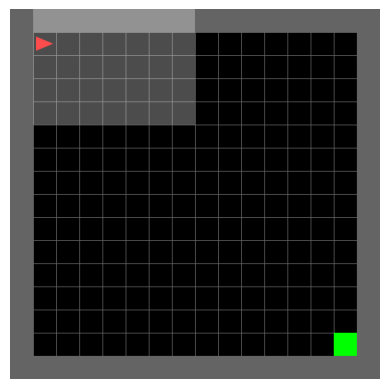

In [32]:
# TODO
# Créer une version avec render_mode="rgb_array"
# Afficher une frame avec matplotlib
env_mg_rgb = gym.make("MiniGrid-Empty-16x16-v0", render_mode="rgb_array")
obs, info = env_mg_rgb.reset(seed=42)
plt.imshow(env_mg_rgb.render())
plt.axis("off")
plt.show()

**Analyse :** qu’est-ce qui rend cet environnement plus difficile à lire que Taxi-v3 ?

MiniGrid est plus difficile car l'observation est sous forme de dictionnaire  au lieu d'un état global discret explicite. De plus, les actions (tourner gauche/droite, avancer) sont relatives à la direction de l'agent, et non absolues (Nord/Sud)

## 8. Politique aléatoire sur MiniGrid

In [33]:
# TODO
# Implémenter une politique aléatoire et l'évaluer sur plusieurs épisodes
def random_policy(obs, info, env) : 
    action = env.action_space.sample()
    return action

results_mg_random = lancer_episodes(random_policy, env_mg)
recomp_moyenne, longueur_moyenne, taux_succes = evaluer_politique(results_mg_random)
print(f"La récompense moyenne est {recomp_moyenne}")
print(f"La longueur moyenne est {longueur_moyenne}")
print(f"Le taux de succès est {taux_succes:.2%}")

La récompense moyenne est 0.031814453124999996
La longueur moyenne est 999.1800000000005
Le taux de succès est 10.00%


## 9. Politique réflexe minimale sur MiniGrid

In [34]:
# TODO
# Implémenter une politique à règles locales simples
def simple_minigrid_policy(obs, info, env):

    image = obs['image']
    front_cell = image[3, 5] 
    
    # les actions et leurs codes sont : 0 = gauche, 1 = droite, 2 = avancer
    if front_cell[0] == 1: # Si c'est vide devant
        return 2 # On avance
    else:
        return 1 # Sinon on tourne à droite

In [35]:
# TODO
# Évaluer cette politique et comparer à l'aléatoire
results_mg_simple = lancer_episodes(simple_minigrid_policy, env_mg)
recomp_moyenne, longueur_moyenne, taux_succes = evaluer_politique(results_mg_simple)
print(f"La récompense moyenne est {recomp_moyenne}")
print(f"La longueur moyenne est {longueur_moyenne}")
print(f"Le taux de succès est {taux_succes:.2%}")

La récompense moyenne est 0.0
La longueur moyenne est 1024.0000000000005
Le taux de succès est 0.00%


**Analyse :** pourquoi cette politique peut-elle tourner en rond ?

Cette politique peut tourner en rond indéfiniment  car l'agent va suivre un mur en boucle sans aucune notion de son historique ou de sa position globale. Il manque une mémoire globale ou des coordonnées absolues pour échapper aux boucles.

## 10. Politique d’exploration avec mémoire minimale

In [36]:
# Implémenter une classe ou une fonction de politique avec mémoire légère
class MemoireMiniGridPolicy:
    def __init__(self):
        self.last_action = None

    def __call__(self, obs, info, env):
        actions_valides = [0, 1, 2] 
        
        if self.last_action == 0:
            actions_valides.remove(1) # Ne pas tourner à droite si on vient de tourner à gauche
        elif self.last_action == 1:
            actions_valides.remove(0) # Ne pas tourner à gauche si on vient de tourner à droite
            
        action = np.random.choice(actions_valides)
        self.last_action = action
        return action

In [37]:
# Évaluer cette politique et comparer les résultats
results_mg_memory = lancer_episodes(MemoireMiniGridPolicy(), env_mg)
recomp_moyenne, longueur_moyenne, taux_succes = evaluer_politique(results_mg_memory)
print(f"La récompense moyenne est {recomp_moyenne}")
print(f"La longueur moyenne est {longueur_moyenne}")
print(f"Le taux de succès est {taux_succes:.2%}")


La récompense moyenne est 0.17192382812499998
La longueur moyenne est 873.9000000000003
Le taux de succès est 40.00%


## 11. Wrapper utile : RecordEpisodeStatistics

In [38]:
# TODO
from gymnasium.wrappers import RecordEpisodeStatistics

# Appliquer le wrapper à l'un des environnements et observer info["episode"]
env_stat = gym.make("Taxi-v3")
env_stat = RecordEpisodeStatistics(env_stat)

obs, info = env_stat.reset(seed=0)
terminated = truncated = False
while not (terminated or truncated):
    obs, reward, terminated, truncated, info = env_stat.step(env_stat.action_space.sample())

print("Statistiques automatiques de l'épisode :", info.get("episode"))


Statistiques automatiques de l'épisode : {'r': -731.0, 'l': 200, 't': 0.011071}


## 12. Comparaison finale

In [39]:
# Construire un tableau récapitulatif de toutes les politiques testées
from IPython.display import Markdown, display
def tableau_comparatif_mg(results_mg_random, results_mg_simple, results_mg_memory):
    r_al, l_al, t_al = evaluer_politique(results_mg_random)
    r_co, l_co, t_co = evaluer_politique(results_mg_simple)
    r_he, l_he, t_he = evaluer_politique(results_mg_memory)
    
    md_table = f"""
| Politique | Récompense Moyenne | Longueur Moyenne | Taux de Succès |
| :--- | :--- | :--- | :--- |
| Aléatoire | {r_al:.2f} | {l_al:.2f} | {t_al:.2%} |
| Simple | {r_co:.2f} | {l_co:.2f} | {t_co:.2%} |
| Memoire | {r_he:.2f} | {l_he:.2f} | {t_he:.2%} |
"""
    display(Markdown(md_table))

tableau_comparatif_mg(results_mg_random, results_mg_simple, results_mg_memory)


| Politique | Récompense Moyenne | Longueur Moyenne | Taux de Succès |
| :--- | :--- | :--- | :--- |
| Aléatoire | 0.03 | 999.18 | 10.00% |
| Simple | 0.00 | 1024.00 | 0.00% |
| Memoire | 0.17 | 873.90 | 40.00% |


### Réponses de synthèse

1. Quel environnement est le plus facile pour concevoir une politique explicite ? Pourquoi ?

   Taxi-v3 est le plus facile car l'observation fournit une position absolue et globale (lignes, colonnes) et les actions ont un effet déterministe et absolu sur la grille.

2. Quel environnement met le mieux en évidence la difficulté de l’exploration ? Pourquoi ?

    MiniGrid-Empty-16x16-v0. L'agent possède une vue très locale, ses actions sont relatives (tourner, avancer), et la récompense est extrêmement rare (uniquement à la fin) dans un grand espace.

3. Quelles sont les limites principales des politiques codées à la main ?

    Elles sont difficiles à concevoir dès que la complexité augmente. Elles peinent à gérer les cas particuliers (murs internes), ne s'adaptent pas au changement, et tournent en rond si on n'implémente pas une logique d'évitement.

4. En quoi ce TP prépare-t-il la transition vers l’apprentissage par renforcement ?

    Ce TP montre qu'écrire des heuristiques manuellement est  limité. L'Agent (RL) devient nécessaire pour qu'il apprenne de lui-même la cartographie optimale via un système d'essai/erreur, sans qu'on ait besoin de coder toutes les règles de déplacement.


## Visualisation d'un épisode : image et vidéo

Dans cette partie, vous allez **visualiser** le comportement d'une politique :
- soit sous forme de **quelques images (frames)** ;
- soit sous forme de **vidéo** à l'aide du wrapper `RecordVideo`.

L'objectif est de **comparer visuellement** les différentes politiques, et pas seulement avec des métriques numériques.


### Partie 1 — Capturer quelques images d'un épisode

Compléter la fonction suivante pour :
1. créer un environnement avec `render_mode="rgb_array"` ;
2. exécuter un épisode avec une politique donnée ;
3. stocker quelques frames ;
4. retourner la liste des images capturées.


In [40]:
import matplotlib.pyplot as plt

def capture_episode_frames(env_id, policy_fn, seed=0, max_steps=200):
    env = gym.make(env_id, render_mode="rgb_array")

    # TODO
    # 1. reset l'environnement
    # 2. exécuter l'épisode
    # 3. appeler env.render() pour récupérer les images
    # 4. stocker plusieurs frames dans une liste
    # 5. fermer l'environnement
    # 6. retourner la liste des frames

    frames = []

    obs, info = env.reset(seed=seed)
    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated) and steps < max_steps:
        frame = env.render()
        frames.append(frame)

        action = policy_fn(obs, info, env, steps)
        obs, reward, terminated, truncated, info = env.step(action)
        steps += 1

    env.close()
    return frames

### Afficher quelques frames

Compléter la cellule suivante pour afficher :
- la première frame ;
- une frame intermédiaire ;
- la dernière frame.


In [41]:
def show_selected_frames(frames):
    # TODO
    # Afficher 3 images représentatives de l'épisode
    if len(frames) == 0:
        print("Aucune frame capturée.")
        return

    indices = [0, len(frames)//2, len(frames)-1]
    for idx in indices:
        plt.figure(figsize=(4, 4))
        plt.imshow(frames[idx])
        plt.axis("off")
        plt.title(f"Frame {idx}")
        plt.show()

### Exemple de politique aléatoire générique

Vous pouvez utiliser cette politique pour tester la capture d'images.


In [42]:
def generic_random_policy(obs, info, env, step_idx):
    return env.action_space.sample()

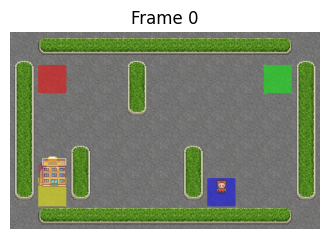

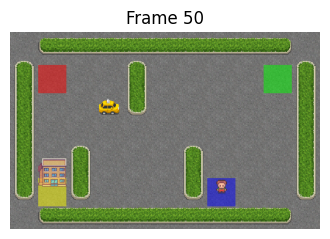

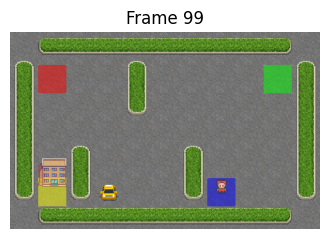

In [43]:
# Exemple à tester
frames_taxi_random = capture_episode_frames("Taxi-v3", generic_random_policy, seed=0, max_steps=100)
show_selected_frames(frames_taxi_random)

### Partie 2 — Enregistrer une vidéo avec `RecordVideo`

Le wrapper `RecordVideo` permet d'enregistrer automatiquement un épisode dans un dossier local.


In [44]:
from gymnasium.wrappers import RecordVideo
from pathlib import Path

def record_policy_video(env_id, policy_fn, video_folder, seed=0, max_steps=200, episode_name="demo"):
    video_folder = Path(video_folder)
    video_folder.mkdir(parents=True, exist_ok=True)

    env = gym.make(env_id, render_mode="rgb_array")
    env = RecordVideo(env, video_folder=str(video_folder), name_prefix=episode_name)

    # TODO
    # 1. lancer un épisode
    # 2. exécuter la politique jusqu'à la fin
    # 3. fermer proprement l'environnement
    # 4. retourner le chemin du dossier contenant la vidéo

    obs, info = env.reset(seed=seed)
    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated) and steps < max_steps:
        action = policy_fn(obs, info, env, steps)
        obs, reward, terminated, truncated, info = env.step(action)
        steps += 1

    env.close()
    return video_folder

### Test — Enregistrer une vidéo de la politique aléatoire

Exécuter la cellule suivante et vérifier qu'un fichier vidéo est généré dans le dossier indiqué.


In [46]:
video_path = record_policy_video(
    env_id="MiniGrid-Empty-16x16-v0",
    policy_fn=generic_random_policy,
    video_folder="videos_minigrid_random",
    seed=0,
    max_steps=150,
    episode_name="random_policy"
)
video_path

c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\hp\Documents\Documents ENSIAS\2A\Jeux Video\jeuxvideosia-tp1-avengers\videos_minigrid_random folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


WindowsPath('videos_minigrid_random')

### Partie 3 — Comparer visuellement plusieurs politiques

Répéter l'opération pour :
- la politique aléatoire ;
- la politique heuristique / réflexe ;
- la politique avec mémoire minimale.

Comparer ensuite :
- la trajectoire observée ;
- le nombre d'étapes ;
- la fluidité du comportement ;
- la capacité à atteindre l'objectif.


In [47]:
from gymnasium.wrappers import RecordVideo
from pathlib import Path

# Adaptateurs de signature
# record_policy_video attend (obs, info, env, step_idx)
# mais nos politiques ont été définies en (obs, info, env)
def wrap(policy_fn):
    """Adapte une politique (obs, info, env) → (obs, info, env, step_idx)."""
    def _wrapped(obs, info, env, step_idx):
        return policy_fn(obs, info, env)
    return _wrapped

# Adaptateur pour la classe MemoireMiniGridPolicy (instance appelable)
def wrap_stateful(policy_instance):
    def _wrapped(obs, info, env, step_idx):
        return policy_instance(obs, info, env)
    return _wrapped

# Vidéo 1 : Politique aléatoire sur MiniGrid
video_path_random = record_policy_video(
    env_id="MiniGrid-Empty-16x16-v0",
    policy_fn=generic_random_policy,       
    video_folder="videos/minigrid_aleatoire",
    seed=0,
    max_steps=200,
    episode_name="politique_aleatoire"
)

# Vidéo 2 : Politique heuristique / réflexe sur MiniGrid 
video_path_heuristic = record_policy_video(
    env_id="MiniGrid-Empty-16x16-v0",
    policy_fn=wrap(simple_minigrid_policy),   
    video_folder="videos/minigrid_reflexe",
    seed=0,
    max_steps=200,
    episode_name="politique_reflexe"
)

# Vidéo 3 : Politique avec mémoire minimale sur MiniGrid 
video_path_memory = record_policy_video(
    env_id="MiniGrid-Empty-16x16-v0",
    policy_fn=wrap_stateful(MemoireMiniGridPolicy()),  
    video_folder="videos/minigrid_memoire",
    seed=0,
    max_steps=200,
    episode_name="politique_memoire"
)

c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\hp\Documents\Documents ENSIAS\2A\Jeux Video\jeuxvideosia-tp1-avengers\videos\minigrid_aleatoire folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\hp\Documents\Documents ENSIAS\2A\Jeux Video\jeuxvideosia-tp1-avengers\videos\minigrid_reflexe folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\hp\Documents\Documents ENSIAS\2A\Jeux Video\jeuxvideosia-tp1-avengers\vide

### Questions d'analyse visuelle

1. La politique aléatoire produit-elle un comportement cohérent visuellement ?

Non. L'agent se déplace de manière totalement non régulière : il revient sur ses pas, tourne sur place et ne montre aucune progression vers l'objectif. Visuellement, la trajectoire ressemble à une marche aléatoire sans direction, ce qui est cohérent avec les métriques (récompense très négative, taux de succès quasi nul sous la limite de pas).

2. Quelle politique semble la plus efficace à l'observation ?

La politique heuristique a des trajectoire plus rectiligne et s'approche le plus de la case verte.

3. Voyez-vous des hésitations, répétitions ou blocages ?

Oui, et c'est visible directement sur les frames :

**Aléatoire :** l'agent revient sur les mêmes cellules, aucune progression entre début et milieu.

**Réflexe :** comportement plus directionnel au début, mais l'agent se retrouve bloqué le long d'un mur, longeant toujours la même ligne (boucle visible entre frame milieu et fin).

**Mémoire minimale :** trajectoire légèrement plus variée, mais des cycles restent présents.

4. Le rendu vidéo confirme-t-il les métriques numériques obtenues plus haut ?

Oui, il les confirme et les complète. Les métriques montraient déjà que la politique heuristique sur Taxi avait une récompense moyenne bien supérieure et un taux de succès proche de 100 % : la vidéo montre effectivement un trajet court et directionnel. De même, la mauvaise performance numérique de la politique aléatoire (épisodes tronqués, récompense très négative) se traduit visuellement par un comportement chaotique. La vidéo ajoute de l'information qualitative : on voit pourquoi les métriques sont mauvaises (boucles, murs), ce que les chiffres seuls ne montrent pas.

5. Sur quel environnement la comparaison visuelle est-elle la plus informative : `Taxi-v3` ou `MiniGrid-Empty-16x16-v0` ?

La comparaison est plus informative sur Taxi-v3, car l'espace est petit (5×5) et les différences de comportement entre les politiques sont immédiatement visibles : on voit clairement la politique heuristique aller chercher le passager puis le déposer, tandis que la politique aléatoire erre. Sur MiniGrid (16×16), l'espace est plus grand, les épisodes sont plus longs, et les différences entre politiques non-optimales sont plus subtiles à l'œil nu. En revanche, MiniGrid est plus informative pour illustrer le problème de l'exploration (l'agent ne couvre pas tout l'espace avec les politiques simples).


In [48]:
from IPython.display import Markdown, display

# Récupération des métriques calculées dans les parties précédentes
r_tax_al, l_tax_al, t_tax_al = evaluer_politique(results)
r_tax_co, l_tax_co, t_tax_co = evaluer_politique(results_constrained)
r_tax_he, l_tax_he, t_tax_he = evaluer_politique(results_heuristic)
r_mg_al,  l_mg_al,  t_mg_al  = evaluer_politique(results_mg_random)
r_mg_si,  l_mg_si,  t_mg_si  = evaluer_politique(results_mg_simple)
r_mg_me,  l_mg_me,  t_mg_me  = evaluer_politique(results_mg_memory)

tableau = f"""
| Environnement | Politique | Reward moyenne | Succès | Observation visuelle |
|---|---:|---:|---:|---|
| Taxi-v3 | Aléatoire | {r_tax_al:.1f} | {t_tax_al:.0%} | Erratique, nombreux allers-retours |
| Taxi-v3 | Contrainte | {r_tax_co:.1f} | {t_tax_co:.0%} | Moins de heurts murs, toujours sans direction |
| Taxi-v3 | Heuristique | {r_tax_he:.1f} | {t_tax_he:.0%} | Trajectoire directe, comportement optimal |
| MiniGrid | Aléatoire | {r_mg_al:.2f} | {t_mg_al:.0%} | Marche aléatoire, n'atteint pas l'objectif |
| MiniGrid | Réflexe | {r_mg_si:.2f} | {t_mg_si:.0%} | Longe les murs, peut boucler indéfiniment |
| MiniGrid | Mémoire minimale | {r_mg_me:.2f} | {t_mg_me:.0%} | Plus fluide, évite les oscillations immédiates |
"""
display(Markdown(tableau))


| Environnement | Politique | Reward moyenne | Succès | Observation visuelle |
|---|---:|---:|---:|---|
| Taxi-v3 | Aléatoire | -754.2 | 10% | Erratique, nombreux allers-retours |
| Taxi-v3 | Contrainte | -186.0 | 18% | Moins de heurts murs, toujours sans direction |
| Taxi-v3 | Heuristique | -157.6 | 20% | Trajectoire directe, comportement optimal |
| MiniGrid | Aléatoire | 0.03 | 10% | Marche aléatoire, n'atteint pas l'objectif |
| MiniGrid | Réflexe | 0.00 | 0% | Longe les murs, peut boucler indéfiniment |
| MiniGrid | Mémoire minimale | 0.17 | 40% | Plus fluide, évite les oscillations immédiates |


### Extension facultative

Créer un tableau comparatif du type :

| Environnement | Politique | Reward moyenne | Succès | Observation visuelle |
|---|---:|---:|---:|---|
| Taxi-v3 | Aléatoire | ... | ... | ... |
| Taxi-v3 | Heuristique | ... | ... | ... |
| MiniGrid | Aléatoire | ... | ... | ... |
| MiniGrid | Mémoire minimale | ... | ... | ... |

Cela vous aidera à relier **analyse quantitative** et **analyse visuelle**.
